# Modelo línea base, sin orden.

### Justificación.
Se usará Random Forest, debido a su capacidad de reducir la varianza de las predicciones. Además este no requiere de datos secuenciales para funcionar y no tenemos que preocuparnos por las escalas.

### Importación de librerías.

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib

### Importación de datos.

In [13]:
df = pd.read_csv('datos_sinteticos.csv', sep = ";")
df.head(2)

,cliente_id,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia,promedio,desviacion,maximo,minimo,monto_hora,moda_establecimiento,cantidad_establecimiento
0,1,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal,879.374333,602.582962,2380.04,240.25,34.208766,Farmacia,7
1,2,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal,346.078000,165.763599,762.78,63.60,16.192467,Otros,5


### Quitando variables que no serán usadas.

In [14]:
df = df.drop(columns=['cliente_id', 'fechas_hora', 'montos', 'tipos_establecimiento', 'historico_establecimiento'])
df.head(2)

,es_anomalia,tipo_anomalia,promedio,desviacion,maximo,minimo,monto_hora,moda_establecimiento,cantidad_establecimiento
0,0,Normal,879.374333,602.582962,2380.04,240.25,34.208766,Farmacia,7
1,0,Normal,346.078000,165.763599,762.78,63.60,16.192467,Otros,5


### Verificando que las variables tengan el tipo correcto.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   es_anomalia               100000 non-null  int64  
 1   tipo_anomalia             100000 non-null  object 
 2   promedio                  100000 non-null  float64
 3   desviacion                100000 non-null  float64
 4   maximo                    100000 non-null  float64
 5   minimo                    100000 non-null  float64
 6   monto_hora                100000 non-null  float64
 7   moda_establecimiento      100000 non-null  object 
 8   cantidad_establecimiento  100000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 6.9+ MB


### Separando las variables predictoras de la objetivo.

In [16]:
X = df.drop(columns = ['es_anomalia'])
y = df['es_anomalia']

### Separación del conjunto de prueba y entrenamiento.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=X['tipo_anomalia'])

In [18]:
X_train = X_train.drop(columns=['tipo_anomalia'])
X_test = X_test.drop(columns=['tipo_anomalia'])

### Pipeline.

In [19]:
preprocesador = ColumnTransformer([("categoricas", OneHotEncoder(drop="first", handle_unknown="ignore"),
                                    make_column_selector(dtype_exclude="number"))], remainder="passthrough")
pipeline = Pipeline([("preprocesamiento", preprocesador), ("modelo", RandomForestClassifier(random_state=0, n_jobs=1))])

### Rejilla de hiperparámetros.

In [20]:
parametros = {"modelo__n_estimators": [50, 100, 200],
              "modelo__max_depth": [None, 3, 5, 7],
              "modelo__min_samples_split": [2, 4, 6],
              "modelo__min_samples_leaf": [1, 2, 4],
              "modelo__max_features": ["sqrt", "log2"],
              "modelo__class_weight": ["balanced_subsample"]}

### GridSearch.

In [21]:
grid_search = GridSearchCV(pipeline, parametros, scoring="average_precision", cv=5, n_jobs=-1, verbose=2, refit=True)

### Entrenamiento del modelo.

In [22]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'modelo__class_weight': ['balanced_subsample'], 'modelo__max_depth': [None, 3, ...], 'modelo__max_features': ['sqrt', 'log2'], 'modelo__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categoricas', ...)]"


### Mejor modelo.

In [23]:
modelo = grid_search.best_estimator_
print('Mejores parámetros')
print(grid_search.best_params_)
print(f"PR-AUC promedio en validación cruzada: {grid_search.best_score_:.4f}")

Mejores parámetros
{'modelo__class_weight': 'balanced_subsample', 'modelo__max_depth': None, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 4, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}
PR-AUC promedio en validación cruzada: 0.2987


### Predicciones.

In [24]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

### Métricas del mejor modelo.

In [25]:
print('Reporte de clasificación')
print(classification_report(y_test, y_pred))
pr_auc = average_precision_score(y_test, y_prob)
print(f"PR-AUC en prueba: {pr_auc:.4f}")

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     17987
           1       0.43      0.22      0.29      2013

    accuracy                           0.89     20000
   macro avg       0.67      0.59      0.61     20000
weighted avg       0.87      0.89      0.88     20000

PR-AUC en prueba: 0.3104


### Matriz de confusión.

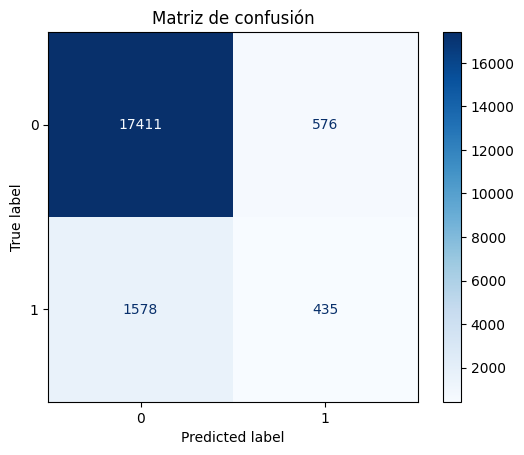

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

### Guardando el mejor modelo.

In [27]:
joblib.dump(modelo, "modelo_A.pkl", compress=3)

['modelo_A.pkl']